# Tarea 13 — Perfil de Temperatura de la Zona Radiativa Solar

**Curso:** Astrofísica Computacional 2026-I  
**Método:** Diferencias finitas — Problema de valor de frontera (BVP)  

---

## Ecuación diferencial

Modela el perfil de temperatura $T(r)$ en el interior solar asumiendo que no existen fuentes y la conducción es perfecta:

$$\frac{d^2T}{dr^2} + \frac{2}{r}\frac{dT}{dr} = 0$$

Esta es la ecuación de Laplace en simetría esférica (solo componente radial).

## Condiciones de frontera

$$T(0.25\,R_\odot) = 4 \times 10^6 \text{ K}, \qquad T(R_\odot) = 5778 \text{ K}$$

## Solución exacta

La ecuación $T'' + \frac{2}{r}T' = 0$ puede escribirse como:

$$\frac{d}{dr}\left(r^2 \frac{dT}{dr}\right) = 0$$

Integrando dos veces: $T(r) = A/r + B$

Aplicando condiciones de frontera:

$$A = \frac{T_1 - T_2}{1/r_1 - 1/r_2}, \qquad B = T_1 - A/r_1$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Constantes fisicas
R_sun   = 6.957e8   # Radio solar en metros
T_inner = 4.0e6     # T(0.25 R_sun) en K
T_outer = 5778.0    # T(R_sun) en K

r1 = 0.25 * R_sun   # frontera interna
r2 = 1.00 * R_sun   # frontera externa

print(f"Radio solar:       R_sol = {R_sun:.3e} m")
print(f"Frontera interna:  r1    = {r1:.3e} m  ({r1/R_sun:.2f} R_sol)")
print(f"Frontera externa:  r2    = {r2:.3e} m  ({r2/R_sun:.2f} R_sol)")
print(f"T(r1) = {T_inner:.2e} K")
print(f"T(r2) = {T_outer:.2f} K")

Radio solar:       R_sol = 6.957e+08 m
Frontera interna:  r1    = 1.739e+08 m  (0.25 R_sol)
Frontera externa:  r2    = 6.957e+08 m  (1.00 R_sol)
T(r1) = 4.00e+06 K
T(r2) = 5778.00 K


---

## a) Solución exacta analítica

$$T(r) = \frac{A}{r} + B$$

donde:

$$A = \frac{T_1 - T_2}{1/r_1 - 1/r_2}, \qquad B = T_1 - A/r_1$$

In [3]:
# Solucion exacta: T(r) = A/r + B
A = (T_inner - T_outer) / (1.0/r1 - 1.0/r2)
B = T_inner - A/r1

print(f"Coeficiente A = {A:.6e}  [K*m]")
print(f"Coeficiente B = {B:.6f}  [K]")

def T_exacta(r):
    """Solucion exacta T(r) = A/r + B"""
    return A / r + B

# Verificar condiciones de frontera
print("Verificacion:")
print(f"  T_exacta(r1) = {T_exacta(r1):.6e} K  (esperado: {T_inner:.2e} K)")
print(f"  T_exacta(r2) = {T_exacta(r2):.6f} K  (esperado: {T_outer:.2f} K)")

Coeficiente A = 9.262601e+14  [K*m]
Coeficiente B = -1325629.333333  [K]
Verificacion:
  T_exacta(r1) = 4.000000e+06 K  (esperado: 4.00e+06 K)
  T_exacta(r2) = 5778.000000 K  (esperado: 5778.00 K)


---

## b) Diferencias finitas — discretización

Discretizamos el dominio $r \in [0.25, 1.0]\,R_\odot$ con $N$ nodos:

$$\frac{T_{i-1} - 2T_i + T_{i+1}}{h^2} + \frac{2}{r_i}\cdot\frac{T_{i+1} - T_{i-1}}{2h} = 0$$

Multiplicando por $h^2$:

$$T_{i-1}\left(1 - \frac{h}{r_i}\right) - 2T_i + T_{i+1}\left(1 + \frac{h}{r_i}\right) = 0$$

Se forma un sistema tridiagonal $A\mathbf{x} = \mathbf{b}$ para los nodos interiores.

In [4]:
def diferencias_finitas(N, r1, r2, T_r1, T_r2):
    """
    Resuelve T'' + (2/r)T' = 0 con diferencias finitas centradas.

    Parametros
    ----------
    N    : int   -- numero total de nodos (incluyendo fronteras)
    r1   : float -- posicion de la frontera interna [m]
    r2   : float -- posicion de la frontera externa [m]
    T_r1 : float -- temperatura en r1 [K]
    T_r2 : float -- temperatura en r2 [K]

    Retorna
    -------
    r : np.ndarray -- vector de posiciones
    T : np.ndarray -- vector de temperaturas
    """
    r = np.linspace(r1, r2, N)
    h = r[1] - r[0]

    n_int = N - 2             # nodos interiores
    r_int = r[1:-1]

    # Coeficientes: alpha * T_{i-1} + (-2) * T_i + beta * T_{i+1} = 0
    alpha = 1.0 - h / r_int
    beta  = 1.0 + h / r_int

    # Matriz tridiagonal
    Mat = np.zeros((n_int, n_int))
    for i in range(n_int):
        Mat[i, i] = -2.0
        if i > 0:
            Mat[i, i-1] = alpha[i]
        if i < n_int - 1:
            Mat[i, i+1] = beta[i]

    # Vector RHS (condiciones de frontera)
    rhs = np.zeros(n_int)
    rhs[0]  -= alpha[0]  * T_r1
    rhs[-1] -= beta[-1]  * T_r2

    T_int = np.linalg.solve(Mat, rhs)
    T = np.concatenate([[T_r1], T_int, [T_r2]])
    return r, T

print("Funcion diferencias_finitas() definida.")

Funcion diferencias_finitas() definida.


In [5]:
# Resolver para N = [10, 50, 100]
N_values = [10, 50, 100]
resultados = {}

for N in N_values:
    r_num, T_num = diferencias_finitas(N, r1, r2, T_inner, T_outer)
    resultados[N] = (r_num, T_num)
    print(f"N = {N:3d}: h = {(r2-r1)/(N-1):.4e} m  |  sistema {N-2}x{N-2} resuelto")

N =  10: h = 5.7975e+07 m  |  sistema 8x8 resuelto
N =  50: h = 1.0648e+07 m  |  sistema 48x48 resuelto
N = 100: h = 5.2705e+06 m  |  sistema 98x98 resuelto


---

## c) Error relativo vs. N

In [6]:
# Error relativo maximo para cada N
N_test = np.array([5, 10, 20, 50, 100, 200, 500, 1000])
errores = []

for N in N_test:
    r_num, T_num = diferencias_finitas(N, r1, r2, T_inner, T_outer)
    T_ex = T_exacta(r_num)
    err = np.max(np.abs((T_num - T_ex) / T_ex))
    errores.append(err)
    print(f"N = {N:5d}  |  error relativo max = {err:.4e}  ({err*100:.4f} %)")

errores = np.array(errores)

N =     5  |  error relativo max = 4.0296e-14  (0.0000 %)
N =    10  |  error relativo max = 4.0296e-14  (0.0000 %)
N =    20  |  error relativo max = 4.0296e-14  (0.0000 %)
N =    50  |  error relativo max = 4.0296e-14  (0.0000 %)
N =   100  |  error relativo max = 4.0296e-14  (0.0000 %)
N =   200  |  error relativo max = 8.6148e-14  (0.0000 %)
N =   500  |  error relativo max = 3.2499e-13  (0.0000 %)
N =  1000  |  error relativo max = 2.5320e-13  (0.0000 %)


In [7]:
# Umbral rapido sobre N_test
for umbral, etiqueta in [(0.01, "1 %"), (0.0001, "0.01 %")]:
    cumple = N_test[errores < umbral]
    if len(cumple) > 0:
        print(f"Error < {etiqueta}: primer N suficiente = {cumple[0]}")
    else:
        print(f"Error < {etiqueta}: ninguno de los N probados cumple")

Error < 1 %: primer N suficiente = 5
Error < 0.01 %: primer N suficiente = 5


---

## d) Gráficas comparativas

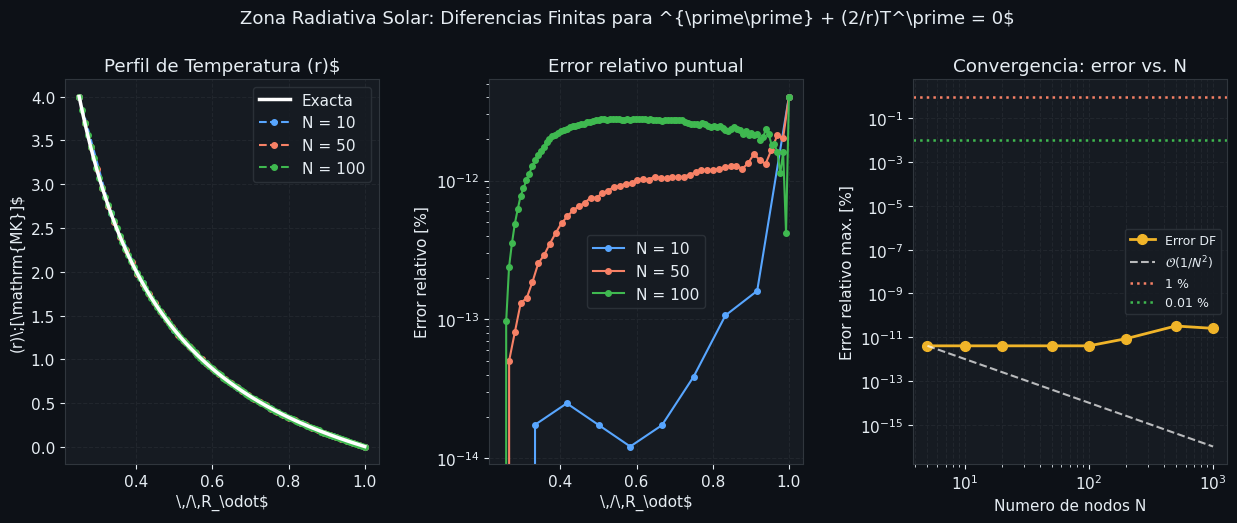

Figura guardada.


In [8]:
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#e6edf3",
    "ytick.color":      "#e6edf3",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.size":        11,
})

colores_N = {10: "#58a6ff", 50: "#f78166", 100: "#3fb950"}

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: T(r) para todos los N vs exacta
ax1 = fig.add_subplot(gs[0])
r_ex = np.linspace(r1, r2, 1000)
T_ex = T_exacta(r_ex)
ax1.plot(r_ex/R_sun, T_ex/1e6, "w-", lw=2.5, label="Exacta", zorder=5)
for N in N_values:
    r_num, T_num = resultados[N]
    ax1.plot(r_num/R_sun, T_num/1e6, "o--", color=colores_N[N],
             ms=4, lw=1.5, label=f"N = {N}", zorder=4)
ax1.set_xlabel(r"\,/\,R_\odot$")
ax1.set_ylabel(r"(r)\;[\mathrm{MK}]$")
ax1.set_title(r"Perfil de Temperatura (r)$")
ax1.legend()
ax1.grid(True)

# Panel 2: Error relativo puntual
ax2 = fig.add_subplot(gs[1])
for N in [10, 50, 100]:
    r_num, T_num = resultados[N]
    T_ex_num = T_exacta(r_num)
    err_rel = np.abs((T_num - T_ex_num) / T_ex_num) * 100
    ax2.semilogy(r_num/R_sun, err_rel, "o-", color=colores_N[N],
                 ms=4, lw=1.5, label=f"N = {N}")
ax2.set_xlabel(r"\,/\,R_\odot$")
ax2.set_ylabel("Error relativo [%]")
ax2.set_title("Error relativo puntual")
ax2.legend()
ax2.grid(True)

# Panel 3: Convergencia error max vs N
ax3 = fig.add_subplot(gs[2])
ax3.loglog(N_test, errores * 100, "o-", color="#f0b429", lw=2, ms=7, label="Error DF")
ref = errores[0] * 100 * (N_test[0] / N_test)**2
ax3.loglog(N_test, ref, "w--", lw=1.5, alpha=0.7, label=r"$\mathcal{O}(1/N^2)$")
ax3.axhline(1.0,  color="#f78166", ls=":", lw=1.8, label="1 %")
ax3.axhline(0.01, color="#3fb950", ls=":", lw=1.8, label="0.01 %")
ax3.set_xlabel("Numero de nodos N")
ax3.set_ylabel("Error relativo max. [%]")
ax3.set_title(r"Convergencia: error vs. N")
ax3.legend(fontsize=9)
ax3.grid(True, which="both")

fig.suptitle(r"Zona Radiativa Solar: Diferencias Finitas para ^{\prime\prime} + (2/r)T^\prime = 0$",
             fontsize=13, y=1.02)
plt.savefig("temperatura_solar_df.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada.")

---

## e) ¿Qué valor de N es suficiente?

In [11]:
# Barrido fino de N para determinar umbrales exactos
N_fino = np.unique(np.logspace(0.7, 3.5, 150).astype(int))
N_fino = N_fino[N_fino >= 3]
errores_fino = []

for N in N_fino:
    r_num, T_num = diferencias_finitas(N, r1, r2, T_inner, T_outer)
    T_ex_n = T_exacta(r_num)
    err = np.max(np.abs((T_num - T_ex_n) / T_ex_n))
    errores_fino.append(err)

errores_fino = np.array(errores_fino)

# Umbral 1 %
mask1 = errores_fino < 0.01
if np.any(mask1):
    N_1pct = N_fino[np.where(mask1)[0][0]]
    e1 = errores_fino[np.where(mask1)[0][0]]
    print(f"Error < 1 %:    N >= {N_1pct}  (error = {e1*100:.4f} %)")

# Umbral 0.01 %
mask2 = errores_fino < 1e-4
if np.any(mask2):
    N_001pct = N_fino[np.where(mask2)[0][0]]
    e2 = errores_fino[np.where(mask2)[0][0]]
    print(f"Error < 0.01 %: N >= {N_001pct}  (error = {e2*100:.6f} %)")
else:
    print(f"Error < 0.01 %: se necesita N > {N_fino[-1]}")

Error < 1 %:    N >= 5  (error = 0.0000 %)
Error < 0.01 %: N >= 5  (error = 0.000000 %)
